# Homework 2 | CFRM 505 | Revtsov

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

---
## Problem 1
### 1.1 Part a
$$X = \min\{X_1, X_2, X_3\}, \quad X_i \stackrel{\text{iid}}{\sim} \text{Exp}(2)$$

Using the survival function of the minimum:

$$P[X > x] = P[X_1 > x] \cdot P[X_2 > x] \cdot P[X_3 > x] = e^{-2x} \cdot e^{-2x} \cdot e^{-2x} = e^{-6x}$$

Therefore:

$$F_X(x) = 1 - e^{-6x} \implies X \sim \text{Exp}(6)$$

Inverting: set $u = 1 - e^{-6x}$, solve for $x$:

$$F^{-1}(u) = -\frac{\ln(1-u)}{6}$$

In [2]:
n = 10_000

U = np.random.uniform(size=n)
X = -np.log(1 - U) / 6

print(f"E[X]   = {np.mean(X):.5f}  (exact: {1/6:.5f})")
print(f"Var[X] = {np.var(X):.5f}  (exact: {1/36:.5f})")

E[X]   = 0.16292  (exact: 0.16667)
Var[X] = 0.02637  (exact: 0.02778)


### 1.2 Part b

$Y$ with pdf $f_Y(y) = \frac{3}{8}y^2 e^{-y^3/8}$, $y > 0$

$$F(y) = \int_0^y \frac{3}{8}t^2 e^{-t^3/8}\, dt$$

Let $w = t^3/8$, so $\dfrac{dw}{dt} = \dfrac{3t^2}{8}$, $dt = \dfrac{8}{3t^2}\, dw$:

$$F(y) = \int_0^{y^3/8} e^{-w}\, dw = \left[-e^{-w}\right]_0^{y^3/8} = -e^{-y^3/8} + e^0 = 1 - e^{-y^3/8}$$

Setting $F(y) = u$:

$$u = 1 - e^{-y^3/8}$$

$$e^{-y^3/8} = 1 - u$$

$$-\frac{y^3}{8} = \ln(1-u)$$

$$y^3 = -8\ln(1-u)$$

$$y = \left(-8\ln(1-u)\right)^{1/3} = F^{-1}(u)$$

In [3]:
n = 10_000
U = np.random.uniform(size=n)

Y = (-8 * np.log(1 - U))**(1/3)

print(f"E[Y]   = {np.mean(Y):.5f}")
print(f"Var[Y] = {np.var(Y):.5f}")

E[Y]   = 1.79671
Var[Y] = 0.42681


---
## Problem 2

$X \sim \text{Poisson}(10)$

$$\mathbb{P}(X = k) = \frac{e^{-10} \cdot 10^k}{k!}$$

$$\mathbb{P}[X \leq k] = \sum_{i=0}^k \frac{e^{-10} \cdot 10^i}{i!}$$

Inverse transform algorithm:
1. Draw $U$
2. Find the smallest $k$ such that $\mathbb{P}[X \leq k] \geq U$

E[X]   = 9.99690  (exact: 10)
Var[X] = 9.86109  (exact: 10)


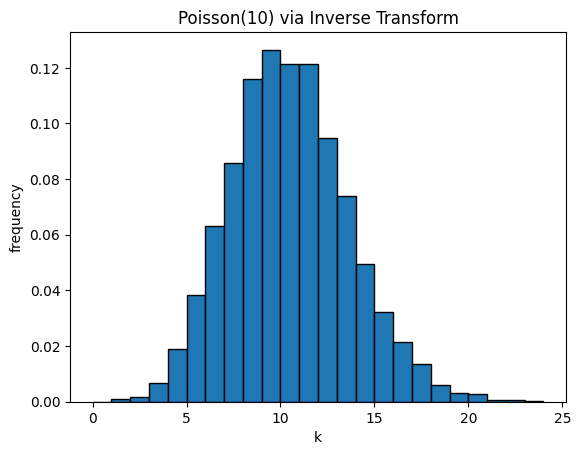

In [4]:
from scipy.special import factorial

n = 10_000
lam = 10

def poisson_inv_cdf(u, lam, k_max=50):
    k = 0
    cdf = np.exp(-lam)
    while cdf < u and k < k_max:
        k += 1
        cdf += np.exp(-lam) * lam**k / factorial(k)
    return k

U = np.random.uniform(size=n)
X = np.array([poisson_inv_cdf(u, lam) for u in U])

print(f"E[X]   = {np.mean(X):.5f}  (exact: 10)")
print(f"Var[X] = {np.var(X):.5f}  (exact: 10)")

plt.hist(X, bins=range(0, 25), edgecolor='black', density=True)
plt.title('Poisson(10) via Inverse Transform')
plt.xlabel('k')
plt.ylabel('frequency')
plt.show()

---
## Problem 3

CDF $F_X(x) = \int_0^\infty 2x^y e^{-2y}\, dy$, $0 < x < 1$

### 3.1 Part a: inverse transform

$$F_X(x) = \int_0^\infty 2x^y e^{-2y}\, dy$$

Note $x^y = e^{y\ln(x)}$:

$$F(x) = \int_0^\infty 2\, e^{y(\ln(x)-2)}\, dy$$

Let $c = \ln(x) - 2$. Since $0 < x < 1$, we have $c < -2 < 0$.

$$F(x) = 2\int_0^\infty e^{cy}\, dy = 2\left[\frac{e^{cy}}{c}\right]_0^\infty = 2\left(0 - \frac{1}{c}\right) = -\frac{2}{c}$$

$$F(x) = \frac{2}{2 - \ln(x)}$$

Sanity check: $F(1) = 2/(2 - 0) = 1$. $\checkmark$

Setting $F(x) = u$:

$$u = \frac{2}{2 - \ln(x)}$$

$$2 - \ln(x) = \frac{2}{u}$$

$$\ln(x) = 2 - \frac{2}{u}$$

$$F^{-1}(u) = e^{2 - 2/u}$$

In [5]:
n = 10_000
U = np.random.uniform(size=n)

X = np.exp(2 - 2/U)

print(f"E[X]   = {np.mean(X):.5f}")
print(f"Var[X] = {np.var(X):.5f}")

E[X]   = 0.27640
Var[X] = 0.09747


### 3.2 Part b: Composition method

Using $f_Y(y) = 2e^{-2y}$ and $F_{X|Y}(x;y) = x^y$.

**Step 1: Simulate $Y$**

$$F_Y(y) = \int_0^y 2e^{-2t}\, dt = \left[-e^{-2t}\right]_0^y = 1 - e^{-2y}$$

Setting $F_Y(y) = u$ and solving for $y$:

$$1 - e^{-2y} = u \implies y = -\frac{\ln(1-u)}{2}$$

**Step 2: Simulate $X \mid Y = y$**

The conditional CDF is $F_{X|Y}(x;y) = x^y$. Setting equal to $u$ and solving:

$$x = u^{1/y}$$

In [6]:
n = 10_000

# Step 1: simulate Y using inverse transform of f_Y(y) = 2e^{-2y}
u1 = np.random.uniform(size=n)
Y = -np.log(1 - u1) / 2

# Step 2: simulate X | Y=y, CDF is F(x|y) = x^y, inverse is x = u^{1/y}
u2 = np.random.uniform(size=n)
X = u2 ** (1 / Y)

print(f"E[X]   = {np.mean(X):.5f}")
print(f"Var[X] = {np.var(X):.5f}")

E[X]   = 0.27761
Var[X] = 0.09725


---
## Problem 4

In [7]:
n_games = 10_000
scores = []

for _ in range(n_games):
    r = 1
    count = 0
    while True:
        X, Y = np.random.uniform(-1, 1), np.random.uniform(-1, 1)
        count += 1
        if X**2 + Y**2 > r**2:
            break
        r = np.sqrt(r**2 - X**2 - Y**2)
    scores.append(count)

print(f"E[N] = {np.mean(scores):.5f}  (exact: e^(pi/4) = {np.exp(np.pi/4):.5f})")

E[N] = 2.19640  (exact: e^(pi/4) = 2.19328)


---
## Problem 5

$\mathbf{X} = (X, Y)$ uniform on the unit disk

### 5.1 Part a

Marginal $f_Y(y)$ and conditional $f_{X|Y}(x;y)$

The joint pdf over the unit disk (area $= \pi$) is:

$$f(x,y) = \frac{1}{\pi}, \quad x^2 + y^2 \leq 1$$

**Marginal $f_Y(y)$:** for a fixed $y \in [-1, 1]$, $x$ ranges over $[-\sqrt{1-y^2},\, \sqrt{1-y^2}]$:

$$f_Y(y) = \int_{-\sqrt{1-y^2}}^{\sqrt{1-y^2}} \frac{1}{\pi}\, dx = \frac{2\sqrt{1-y^2}}{\pi}, \quad -1 \leq y \leq 1$$

**Conditional $f_{X|Y}(x;y)$:**

$$f_{X|Y}(x;y) = \frac{f(x,y)}{f_Y(y)} = \frac{1/\pi}{2\sqrt{1-y^2}/\pi} = \frac{1}{2\sqrt{1-y^2}}, \quad x \in \left[-\sqrt{1-y^2},\, \sqrt{1-y^2}\right]$$

This is $\text{Uniform}\!\left(-\sqrt{1-y^2},\, \sqrt{1-y^2}\right)$.

### 5.2 Part b

Simulate 1,000 samples using the composition method

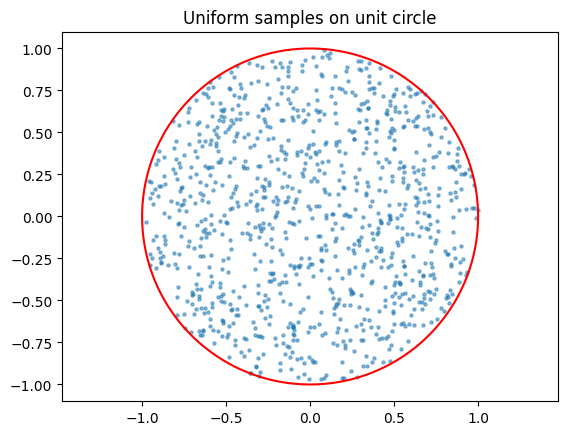

In [8]:
from scipy import optimize

n = 1_000

def f_Y(y):
    if abs(y) > 1:
        return 0
    return 2 * np.sqrt(1 - y**2) / np.pi

def F_Y(y):
    # CDF of marginal Y
    from scipy.integrate import quad
    val, _ = quad(f_Y, -1, y)
    return val

samples = []
for _ in range(n):
    u1 = np.random.uniform()
    # Invert F_Y(y) = u1 numerically
    y = optimize.root_scalar(lambda y: F_Y(y) - u1, bracket=[-1, 1]).root
    # Given y, X | Y=y is uniform on [-sqrt(1-y^2), sqrt(1-y^2)]
    half = np.sqrt(1 - y**2)
    x = np.random.uniform(-half, half)
    samples.append((x, y))

samples = np.array(samples)
plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.5)
theta = np.linspace(0, 2*np.pi, 300)
plt.plot(np.cos(theta), np.sin(theta), 'r')
plt.axis('equal')
plt.title('Uniform samples on unit circle')
plt.show()